In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is NOT available")


✅ GPU is available
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset
train_data = datasets.ImageFolder(
    root="C:\\Users\\amirt\\OneDrive\\Desktop\\finalproject\\Lung Disease Dataset\\train",
    transform=transform
)
val_data = datasets.ImageFolder(
    root="C:\\Users\\amirt\\OneDrive\\Desktop\\finalproject\\Lung Disease Dataset\\val",
    transform=transform
)

print("Detected classes:", train_data.classes)  # ['NORMAL', 'PNEUMONIA']

# Data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

ensemble_size = 3  # Number of models in the ensemble

# Model selection for the ensemble
model_choices = [
    models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1),  # ResNet-50
    models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1),  # DenseNet
    models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)  # EfficientNet
]

for model_idx in range(ensemble_size):
    print(f"\nTraining model {model_idx+1} of {ensemble_size}")
    
    # Select model based on index
    model = model_choices[model_idx]
    
    # Modify the final fully connected layer to match the number of classes in your dataset
    if isinstance(model, models.ResNet):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, len(train_data.classes))
    elif isinstance(model, models.DenseNet):
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, len(train_data.classes))
    elif isinstance(model, models.EfficientNet):
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, len(train_data.classes))
    
    model = model.to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop with checkpointing
    epochs = 1  # Adjust as needed
    best_accuracy = 0.0  # For tracking the best validation accuracy
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_loss:.4f}")

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                _, predicted = torch.max(val_outputs.data, 1)
                total += val_labels.size(0)
                correct += (predicted == val_labels).sum().item()
        
        val_accuracy = 100 * correct / total
        print(f"Validation Accuracy: {val_accuracy:.2f}%")
        
        # Save best model checkpoint for this ensemble member
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            checkpoint_path = f"best_model_{model_idx+1}.pth"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Best model updated and saved as {checkpoint_path} with accuracy: {best_accuracy:.2f}%")
    
    # Optionally save the final model as well (if you want to compare last epoch vs best)
    torch.save(model.state_dict(), f"final_model_{model_idx+1}.pth")
    print(f"Final model for ensemble member {model_idx+1} saved.")

Using device: cuda
Detected classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']

Training model 1 of 3


KeyboardInterrupt: 

Predicted class: 3


  0%|          | 0/1000 [00:00<?, ?it/s]

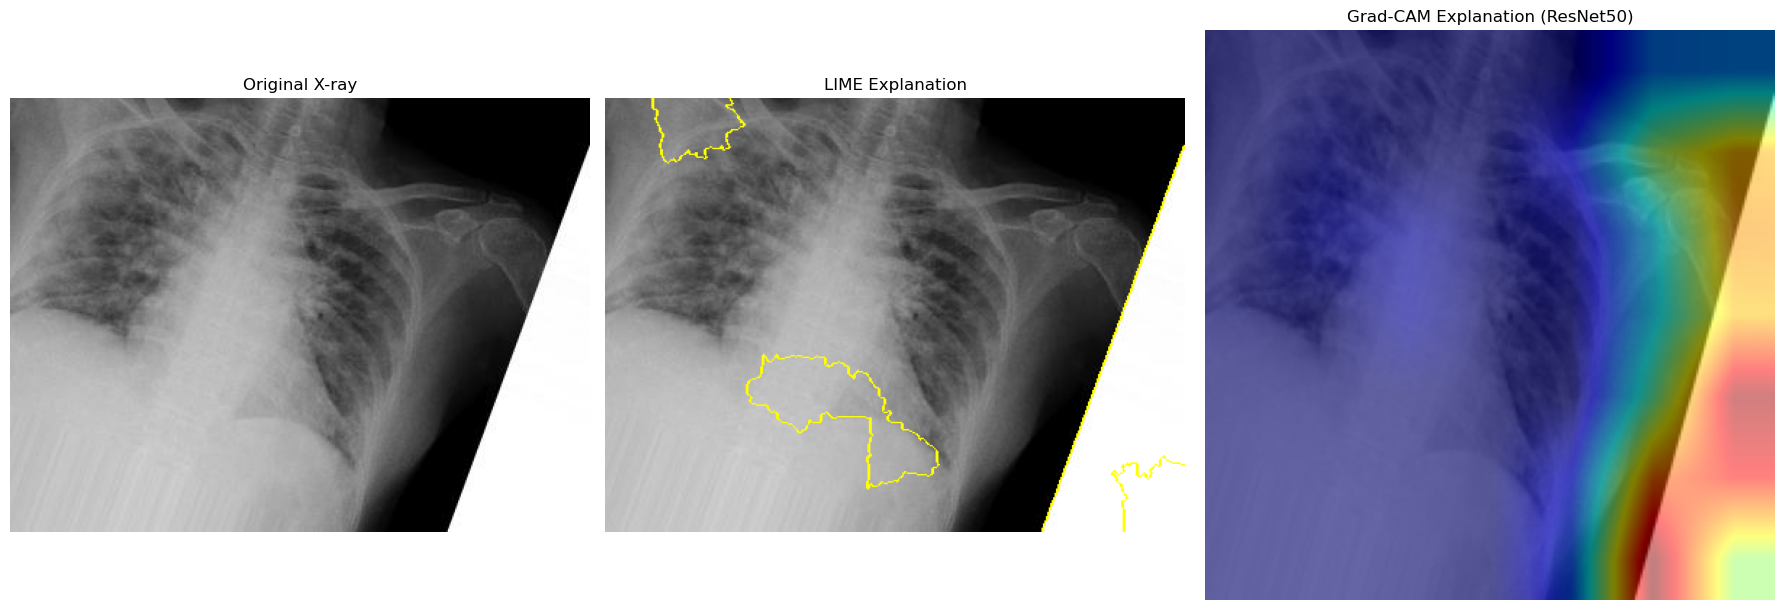

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torchvision.models as models
import torchvision.transforms as transforms

from lime import lime_image
from skimage.segmentation import mark_boundaries

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ensemble models for explanation
model_1 = models.resnet50(weights=None)
model_1.fc = torch.nn.Linear(model_1.fc.in_features, 5)
model_1.load_state_dict(torch.load("best_model_1.pth", map_location=device, weights_only=True))
model_1 = model_1.to(device)
model_1.eval()

model_2 = models.densenet121(weights=None)
model_2.classifier = torch.nn.Linear(model_2.classifier.in_features, 5)
model_2.load_state_dict(torch.load("best_model_2.pth", map_location=device, weights_only=True))
model_2 = model_2.to(device)
model_2.eval()

model_3 = models.efficientnet_b0(weights=None)
model_3.classifier[1] = torch.nn.Linear(model_3.classifier[1].in_features, 5)
model_3.load_state_dict(torch.load("best_model_3.pth", map_location=device, weights_only=True))
model_3 = model_3.to(device)
model_3.eval()

ensemble_models = [model_1, model_2, model_3]

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load image
image_path = "C:\\Users\\amirt\\OneDrive\\Desktop\\finalproject\\Lung Disease Dataset\\test\\Corona Virus Disease\\_21_3861426.jpeg"
image_pil = Image.open(image_path).convert("RGB")
input_tensor = transform(image_pil).unsqueeze(0).to(device)

# Get predicted class from ensemble
with torch.no_grad():
    outputs = [model(input_tensor) for model in ensemble_models]
    avg_logits = torch.mean(torch.stack(outputs), dim=0)
    predicted_class = int(torch.argmax(avg_logits, dim=1).item())

print(f"Predicted class: {predicted_class}")

# LIME: Batch prediction
def batch_predict(images_np):
    batch = torch.stack([
        transform(Image.fromarray(img).convert("RGB")) for img in images_np
    ], dim=0).to(device)

    with torch.no_grad():
        outputs = [model(batch) for model in ensemble_models]
        logits = torch.mean(torch.stack(outputs), dim=0)
    return logits.cpu().numpy()

# LIME Explanation
def get_lime_explanation(pil_img, target_class):
    explainer = lime_image.LimeImageExplainer()
    img_np = np.array(pil_img)

    explanation = explainer.explain_instance(
        img_np,
        batch_predict,
        labels=(target_class,),
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    if target_class not in explanation.local_exp:
        raise ValueError(f"Target class {target_class} not found in LIME explanation.")

    lime_img, mask = explanation.get_image_and_mask(
        label=target_class,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    return lime_img, mask

# Grad-CAM Explanation (using ResNet50)
def get_gradcam_overlay(input_tensor, image_pil, target_class):
    model_for_cam = model_1
    target_layers = [model_for_cam.layer4[-1]]

    cam = GradCAM(model=model_for_cam, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])[0]

    img_np = np.array(image_pil.resize((224, 224))).astype(np.float32) / 255.0
    if img_np.shape[-1] == 4:
        img_np = img_np[..., :3]

    return show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# Generate explanations
lime_img, lime_mask = get_lime_explanation(image_pil, predicted_class)
gradcam_img = get_gradcam_overlay(input_tensor, image_pil, predicted_class)

# Display
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(np.array(image_pil))
axs[0].set_title("Original X-ray")
axs[0].axis("off")

axs[1].imshow(mark_boundaries(lime_img / 255.0, lime_mask))
axs[1].set_title("LIME Explanation")
axs[1].axis("off")

axs[2].imshow(gradcam_img)
axs[2].set_title("Grad-CAM Explanation (ResNet50)")
axs[2].axis("off")

plt.tight_layout()
plt.savefig("lime_gradcam_comparison.png")
plt.show()

In [7]:
import torch
import numpy as np
from PIL import Image
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names (update if needed)
class_names = ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']

# Image transform - MUST match training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Clean DataParallel keys
def clean_state_dict(state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    return new_state_dict

# Robust model loading function
def load_model(checkpoint_path):
    # Initialize the ResNet model
    model = models.resnet50(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                state_dict = clean_state_dict(checkpoint['model_state_dict'])
            elif 'state_dict' in checkpoint:
                state_dict = clean_state_dict(checkpoint['state_dict'])
            else:
                state_dict = clean_state_dict(checkpoint)
            model.load_state_dict(state_dict, strict=False)  # Use strict=False to handle missing keys

        else:
            # If entire model was saved (e.g., torch.save(model))
            model = checkpoint

    except Exception as e:
        print(f"❌ Failed to load {checkpoint_path}: {e}")
        raise

    model.to(device)
    model.eval()
    return model

# Load ensemble models
ensemble_paths = ["best_model_1.pth", "best_model_2.pth", "best_model_3.pth"]
ensemble_models = [load_model(path) for path in ensemble_paths]

# Prediction function
def predict_xray(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    predictions = []
    with torch.no_grad():
        for model in ensemble_models:
            output = model(input_tensor)
            pred = torch.argmax(output, dim=1).item()
            predictions.append(pred)

    # Majority vote
    final_prediction = max(set(predictions), key=predictions.count)
    label = class_names[final_prediction]

    print(f"✅ Final predicted label (majority vote): {label}")


    return input_tensor, image, final_prediction

# Example test
test_image_path = r"C:\\Users\\amirt\\OneDrive\\Desktop\\finalproject\\Lung Disease Dataset\\test\\Corona Virus Disease\\_21_3861426.jpeg"
input_tensor, original_pil, final_pred = predict_xray(test_image_path)

✅ Final predicted label (majority vote): Corona Virus Disease
